# Diabetes prediction model
### Problem & Objective Defination
- Given some data based on glucose, BMI etc can you predict whether a person is diabetic
- This is a classification problem either:
     - A person is diabetic
     - Or non-diabetic
- In the end the model should have a high accuracy score
- In confusion matrix the False positives are costly mistakes

# Data Undestanding and cleaning
## Importing dependancies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize

## Data Understanding

In [3]:
# read csv file
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
data.shape

(768, 9)

- The data has 768 rows and 9 columns
- The data is a calssification problem, the target variable is the ```Outcome``` column
- In the target variable the ```1 -> represents a diabetic person``` and ```0 -> represents a non-diabetic person```

In [6]:
# get the value count of the target variable
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- Our data has ```768 people``` of this ```500 are non-diabetic``` and ```268 are diabetic```
- This data is bias and using it to train our model could make our model bias

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- The above tells that there is a big range between the maximum and minmum values and I will have to scale this data

## Data PreProcessing and Cleaning

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

- Our data has no null values

#### Outliers

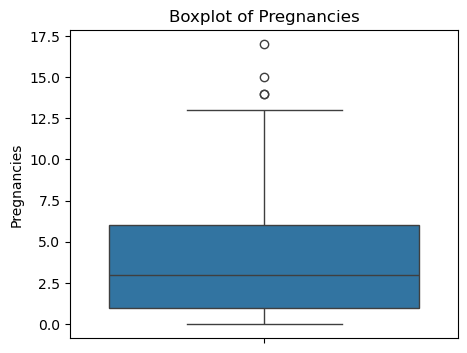

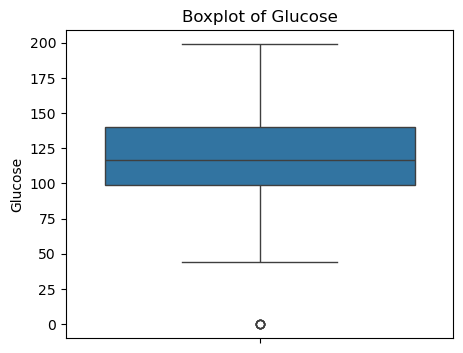

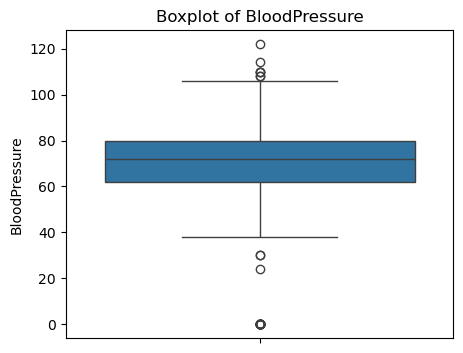

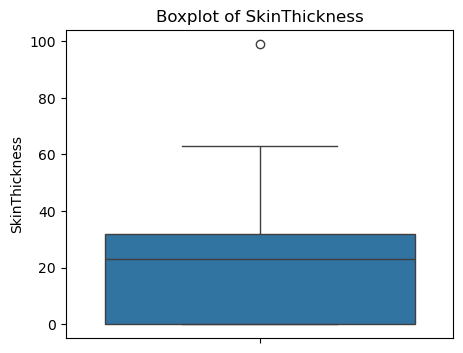

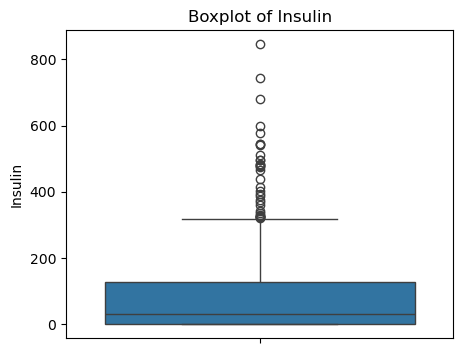

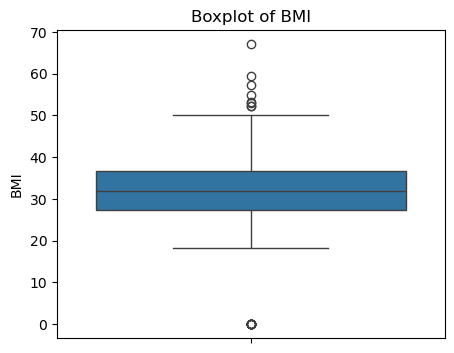

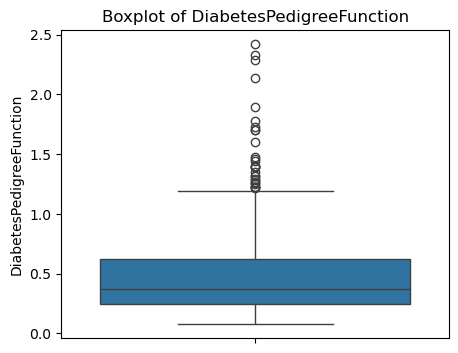

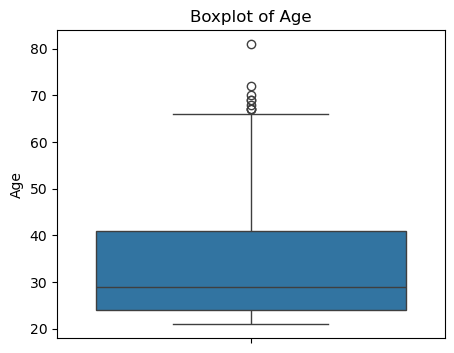

In [10]:
outlier_data_check = data.drop('Outcome', axis=1)

def check_outliers_in_data(df):
    ''' Function to check for outliers in a given df using boxplot'''
    for i in df.columns:
        plt.figure(figsize=(5,4))
        sns.boxplot(df[i])
        plt.title(f"Boxplot of {i}")
        plt.show()

def check_distribution_in_data(df):
    '''Function to check distribution in a given df using Histogram'''
    for col in df.columns:
        plt.figure(figsize=(5, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Histogram of {col}")
        plt.show()

def calculate_skewness(df):
    """Function to calculate skewness of columns in a give dataframe"""
    for col in df.columns:
        print(f"Skewness of {col} is : ", df[col].skew())

check_outliers_in_data(outlier_data_check)

- Our data has outliers on every independent feature, we need to remove these outliers because:
    - They reduce the model accuracy
    - The can give misleading visualizations
    - They result in skewd Statistical Measures

#### Handling Outliers

In [11]:
## Removing the Outliers using the Interquatile Range Method
remove_outlier = data

def remove_outliers_in_data_IQR(df):
    """Function to remove outliers in a given dataframe using IQR"""
    print("df shape before: ", df.shape)
    for col in df.columns:
        if (col != 'Outcome'):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            upper_array = np.where(df[col] >= upper)[0]
            lower_array = np.where(df[col] <= lower)[0]

            df = df[(df[col] >= lower) & (df[col] <= upper)]

    print("df shape after: ",df.shape)
    return df
data_IQRd = remove_outliers_in_data_IQR(remove_outlier)

df shape before:  (768, 9)
df shape after:  (636, 9)


In [12]:
data_IQRd['Outcome'].value_counts()

Outcome
0    439
1    197
Name: count, dtype: int64

In [13]:
# check skewness after IQR
calculate_skewness(data_IQRd)

Skewness of Pregnancies is :  0.8364232948617839
Skewness of Glucose is :  0.6039153998965503
Skewness of BloodPressure is :  0.11327867749183708
Skewness of SkinThickness is :  -0.09543878745008873
Skewness of Insulin is :  1.0871055358032595
Skewness of BMI is :  0.24098789607291218
Skewness of DiabetesPedigreeFunction is :  0.9067025415043078
Skewness of Age is :  1.0030464261506067
Skewness of Outcome is :  0.8248522347604641


- For this data:
    - Pregancies is moderately rightly skewed
    - Glucose is slightly skewed
    - BloodPreassure is almost normal
    - SkinThickness is almost normal
    - Insulin is highly rightly skewed
    - BMI is slightly skewed
    - DPF is moderately rightly skwed
    - Age is highly rightly skewed
    - Outcome we ignore it
- Lets work on ```Pregnacies, Insulin, DPF and Age```

In [14]:
# Handle skewness
columns = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'Age', 'Glucose']

for col in columns:
    data_IQRd[col] = np.log1p(data_IQRd[col])

calculate_skewness(data_IQRd)

Skewness of Pregnancies is :  -0.26349949865491146
Skewness of Glucose is :  -0.021590469542859682
Skewness of BloodPressure is :  0.11327867749183708
Skewness of SkinThickness is :  -0.09543878745008873
Skewness of Insulin is :  -0.021784315557081078
Skewness of BMI is :  0.24098789607291218
Skewness of DiabetesPedigreeFunction is :  0.6130786479957517
Skewness of Age is :  0.5672776070723811
Skewness of Outcome is :  0.8248522347604641


## Feature Engineering

In [15]:
data_IQRd.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

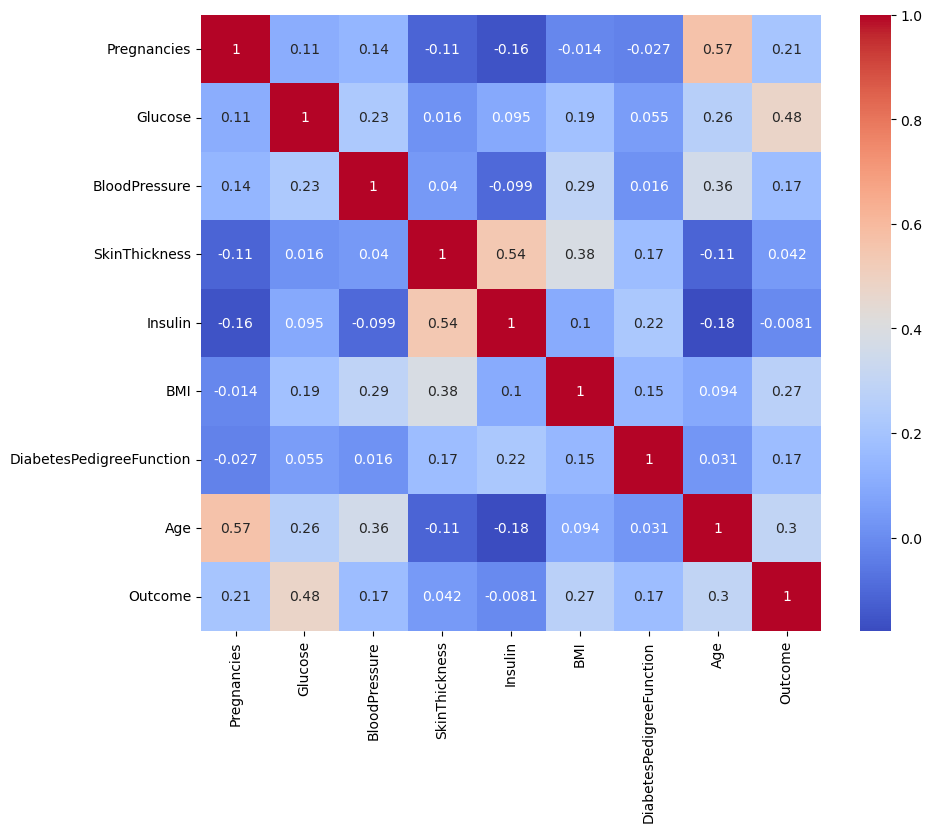

In [16]:
corr = data_IQRd.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

- No two features have a strong correlation ie none is >= 0.7, the available ones are moderate.

## Age risk buckets

In [17]:
data_IQRd['Age'].head()

0    3.931826
1    3.465736
2    3.496508
3    3.091042
5    3.433987
Name: Age, dtype: float64

## Split the data

In [18]:
X = data_IQRd.drop(['Outcome'], axis=1)
y = data_IQRd['Outcome']

print('X shape is: ', X.shape, ' and y shape is: ', y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=47, test_size=0.2)

X shape is:  (636, 8)  and y shape is:  (636,)


# Machine Learning

In [19]:
# # create model
# model = SVC(class_weight='balanced', kernel='rbf')

# # Fit model
# model.fit(X_train_resampled, y_train_resampled)

# Create model
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Recall',
    scale_pos_weight= 439/197, #500/268,   # imbalance handling
    random_state=42,
    verbose=0
)

# Fit model
model.fit(X_train, y_train)

# Predict
y_predictions = model.predict(X_test)

### Accuracy score

In [20]:
acc = accuracy_score(y_test, y_predictions)
acc

0.796875

- We have an accuracy of 76.62% with SVC
- we have an accuracy of 77.7% with CatBoost
- Accuracy increases to 79.69% when outliers are removed
- Accuracy didn't change after fixing skew

### Confusion matrix

[[80  8]
 [18 22]]


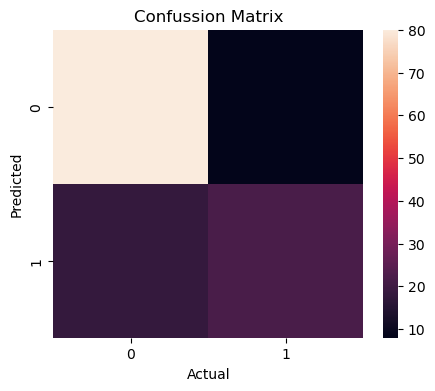

In [21]:
cm = confusion_matrix(y_test, y_predictions, labels=[0, 1])
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm)
plt.title('Confussion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

- 84 non-diabetic persons were predicted correctly
- 34 diabetic persons were predicted correctly
- 16 non-diabetics persons were predicted to have diabetes
- 20 diabetic persons were predicted not to have diabetes

### Classification report

In [22]:
report = classification_report(y_test, y_predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.91      0.86        88
           1       0.73      0.55      0.63        40

    accuracy                           0.80       128
   macro avg       0.77      0.73      0.74       128
weighted avg       0.79      0.80      0.79       128



In [23]:
import joblib

# Save the CatBoost model
model.save_model('diabetes_model.cbm')

# Save the list of features (optional)
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

# Save the list of columns that need log transformation
log_cols = ['Pregnancies', 'Insulin', 'DiabetesPedigreeFunction', 'Age', 'Glucose']
joblib.dump(log_cols, 'log_columns.pkl')

['log_columns.pkl']